# AirDraw — MNIST Data Preprocessing
### Phase 1: Data Collection, Preparation & Preprocessing
**Project:** AirDraw: Hand Gesture Based Digit Recognition System  
**Dataset:** MNIST (70,000 handwritten digit images)  
**Output:** Preprocessed .npy files packaged as .zip

---
## Step 1 — Import Libraries

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

print('All libraries imported successfully!')
print(f'PyTorch version: {torch.__version__}')

All libraries imported successfully!
PyTorch version: 2.11.0+cpu


---
## Step 2 — Load Raw MNIST Dataset (No Preprocessing Yet)

In [2]:
# Load raw dataset — transform=None means NO preprocessing applied yet
train_dataset_raw = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=None
)

test_dataset_raw = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=None
)

print(f'Training samples : {len(train_dataset_raw)}')
print(f'Testing samples  : {len(test_dataset_raw)}')

Training samples : 60000
Testing samples  : 10000


---
## Step 3 — Inspect Raw Data

In [3]:
# Inspect one raw image before any preprocessing
image_raw, label = train_dataset_raw[0]
image_raw_array  = np.array(image_raw)

print(f'Label (correct digit) : {label}')
print(f'Image type            : {type(image_raw)}')
print(f'Image size            : {image_raw.size}')
print(f'Image mode            : {image_raw.mode}  (L = grayscale)')
print(f'Array shape           : {image_raw_array.shape}')
print(f'Pixel value range     : {image_raw_array.min()} to {image_raw_array.max()}')
print(f'Data type             : {image_raw_array.dtype}')
print()
print('Raw pixel values (top-left 10x10 corner):')
print(image_raw_array[:10, :10])

Label (correct digit) : 5
Image type            : <class 'PIL.Image.Image'>
Image size            : (28, 28)
Image mode            : L  (L = grayscale)
Array shape           : (28, 28)
Pixel value range     : 0 to 255
Data type             : uint8

Raw pixel values (top-left 10x10 corner):
[[  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36]
 [  0   0   0   0   0   0   0  49 238 253]
 [  0   0   0   0   0   0   0  18 219 253]
 [  0   0   0   0   0   0   0   0  80 156]]


---
## Step 4 — Visualize Raw Images

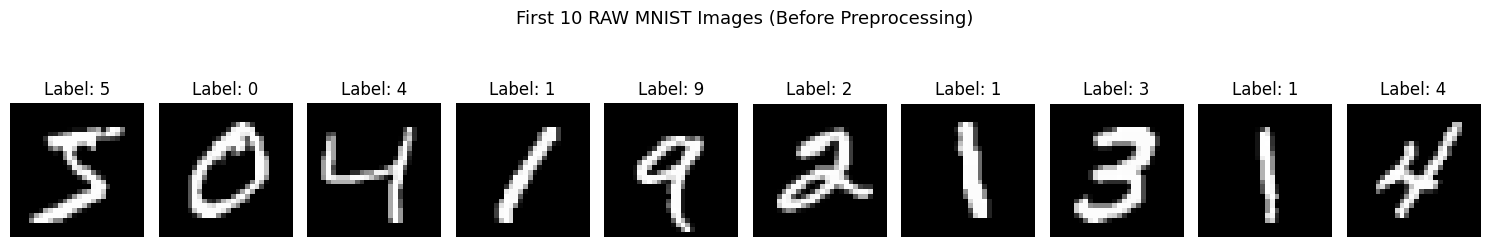

These are RAW images — no preprocessing applied yet


In [4]:
# Display first 10 raw images
fig, axes = plt.subplots(1, 10, figsize=(15, 3))

for i in range(10):
    image, label = train_dataset_raw[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Label: {label}')
    axes[i].axis('off')

plt.suptitle('First 10 RAW MNIST Images (Before Preprocessing)', fontsize=13)
plt.tight_layout()
plt.show()
print('These are RAW images — no preprocessing applied yet')

---
## Step 5 — Apply Preprocessing (Normalization + Conversion + Reshape)

In [5]:
# Define transform pipeline
# transforms.ToTensor() does THREE things automatically:
#   1. Converts PIL Image  → PyTorch Tensor
#   2. Normalizes pixels     0-255 → 0.0-1.0  (divides by 255)
#   3. Reshapes              (28,28) → (1,28,28)  (adds channel dimension)
transform = transforms.Compose([
    transforms.ToTensor()
])

# Reload datasets WITH preprocessing applied
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=False,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=False,
    transform=transform
)

# Verify preprocessing on first image
image_processed, label = train_dataset[0]

print(f'Label                 : {label}')
print(f'Type after processing : {type(image_processed)}')
print(f'New shape             : {image_processed.shape}  (channel, height, width)')
print(f'New pixel range       : {image_processed.min():.4f} to {image_processed.max():.4f}')
print(f'New data type         : {image_processed.dtype}')

Label                 : 5
Type after processing : <class 'torch.Tensor'>
New shape             : torch.Size([1, 28, 28])  (channel, height, width)
New pixel range       : 0.0000 to 1.0000
New data type         : torch.float32


---
## Step 6 — Verify Normalization (Before vs After Comparison)

In [6]:
# Compare raw vs preprocessed pixel values for same image
raw_array       = np.array(train_dataset_raw[0][0])
processed_array = train_dataset[0][0].numpy()

print('BEFORE preprocessing (top-left 10x10 corner):')
print(raw_array[:10, :10])
print()
print('AFTER preprocessing (top-left 10x10 corner):')
print(processed_array[0, :10, :10].round(3))
print()
print('Verification — same pixel divided by 255:')
print(f'  Raw pixel 253   → {253/255:.3f}  (matches preprocessed value)')
print(f'  Raw pixel 0     → {0/255:.3f}   (matches preprocessed value)')

BEFORE preprocessing (top-left 10x10 corner):
[[  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36]
 [  0   0   0   0   0   0   0  49 238 253]
 [  0   0   0   0   0   0   0  18 219 253]
 [  0   0   0   0   0   0   0   0  80 156]]

AFTER preprocessing (top-left 10x10 corner):
[[0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.118 0.141]
 [0.    0.    0.    0.    0.    0.  

---
## Step 7 — One-Hot Encoding of Labels

In [7]:
def one_hot_encode(label, num_classes=10):
    """Convert integer label to one-hot vector of length 10"""
    one_hot = torch.zeros(num_classes)
    one_hot[label] = 1.0
    return one_hot

print('One-Hot Encoding — first 5 labels:')
print()
for i in range(5):
    _, label = train_dataset[i]
    encoded  = one_hot_encode(label)
    print(f"  Digit '{label}' → {encoded.numpy().astype(int)}")

One-Hot Encoding — first 5 labels:

  Digit '5' → [0 0 0 0 0 1 0 0 0 0]
  Digit '0' → [1 0 0 0 0 0 0 0 0 0]
  Digit '4' → [0 0 0 0 1 0 0 0 0 0]
  Digit '1' → [0 1 0 0 0 0 0 0 0 0]
  Digit '9' → [0 0 0 0 0 0 0 0 0 1]


---
## Step 8 — Visual Before vs After Comparison

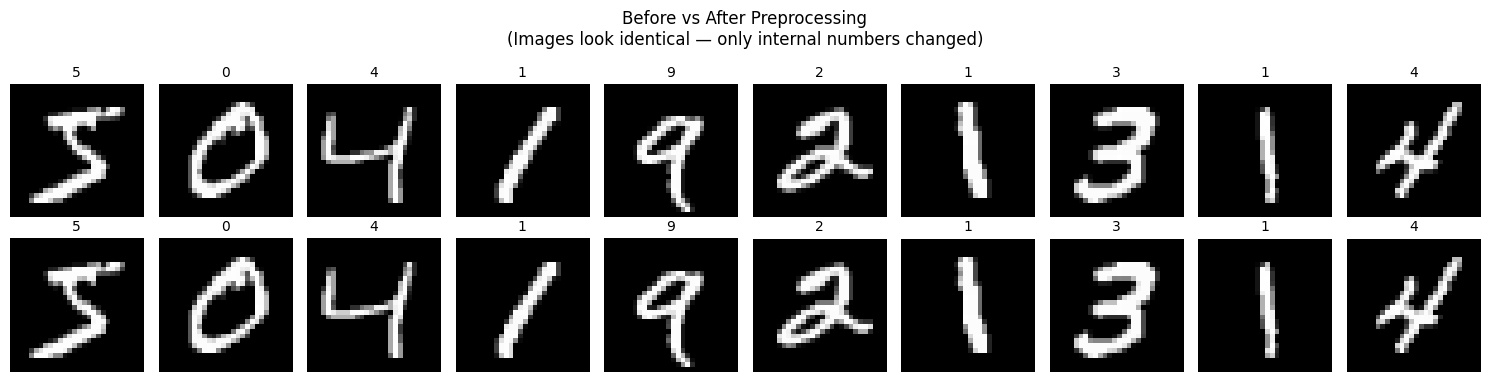

In [8]:
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):
    # TOP ROW — Raw images
    raw_img, label = train_dataset_raw[i]
    axes[0, i].imshow(raw_img, cmap='gray')
    axes[0, i].set_title(str(label), fontsize=10)
    axes[0, i].axis('off')

    # BOTTOM ROW — Preprocessed images
    proc_img, label = train_dataset[i]
    axes[1, i].imshow(proc_img.squeeze(), cmap='gray')
    axes[1, i].set_title(str(label), fontsize=10)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('RAW', fontsize=11, rotation=0, labelpad=40)
axes[1, 0].set_ylabel('PROCESSED', fontsize=11, rotation=0, labelpad=40)

plt.suptitle('Before vs After Preprocessing\n(Images look identical — only internal numbers changed)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Step 9 — Extract and Save All Preprocessed Data

In [9]:
os.makedirs('./preprocessed_mnist', exist_ok=True)

print('Extracting and saving preprocessed data...')
print('Please wait — processing 70,000 images...')
print()

# --- Training Data ---
train_images = []
train_labels = []

for i in range(len(train_dataset)):
    image, label = train_dataset[i]
    train_images.append(image.numpy())
    train_labels.append(label)

train_images = np.array(train_images)
train_labels = np.array(train_labels)

np.save('./preprocessed_mnist/train_images.npy', train_images)
np.save('./preprocessed_mnist/train_labels.npy', train_labels)
print(f'Training data saved — Images: {train_images.shape}, Labels: {train_labels.shape}')

# --- Test Data ---
test_images = []
test_labels = []

for i in range(len(test_dataset)):
    image, label = test_dataset[i]
    test_images.append(image.numpy())
    test_labels.append(label)

test_images = np.array(test_images)
test_labels = np.array(test_labels)

np.save('./preprocessed_mnist/test_images.npy', test_images)
np.save('./preprocessed_mnist/test_labels.npy', test_labels)
print(f'Test data saved     — Images: {test_images.shape}, Labels: {test_labels.shape}')

Extracting and saving preprocessed data...
Please wait — processing 70,000 images...

Training data saved — Images: (60000, 1, 28, 28), Labels: (60000,)
Test data saved     — Images: (10000, 1, 28, 28), Labels: (10000,)


---
## Step 10 — Package as .zip File

In [10]:
zip_filename = 'AirDraw_Preprocessed_MNIST.zip'

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    zipf.write('./preprocessed_mnist/train_images.npy', 'train_images.npy')
    zipf.write('./preprocessed_mnist/train_labels.npy', 'train_labels.npy')
    zipf.write('./preprocessed_mnist/test_images.npy',  'test_images.npy')
    zipf.write('./preprocessed_mnist/test_labels.npy',  'test_labels.npy')

size_mb = os.path.getsize(zip_filename) / (1024 * 1024)
print(f'ZIP file created : {zip_filename}')
print(f'File size        : {size_mb:.1f} MB')
print()
print('Files inside ZIP:')
with zipfile.ZipFile(zip_filename, 'r') as zipf:
    for name in zipf.namelist():
        print(f'   {name}')

ZIP file created : AirDraw_Preprocessed_MNIST.zip
File size        : 209.9 MB

Files inside ZIP:
   train_images.npy
   train_labels.npy
   test_images.npy
   test_labels.npy


---
## Summary

| Step | What Was Done | Result |
|------|--------------|--------|
| 1 | Imported all libraries | PyTorch, torchvision, NumPy, Matplotlib |
| 2 | Loaded raw MNIST | 60,000 train + 10,000 test |
| 3 | Inspected raw data | PIL Image, (28,28), uint8, range 0-255 |
| 4 | Visualized raw images | 10 sample digits displayed |
| 5 | Applied preprocessing | Normalized + Converted + Reshaped |
| 6 | Verified normalization | Values confirmed 0.0-1.0 |
| 7 | One-hot encoded labels | Digit 5 → [0,0,0,0,0,1,0,0,0,0] |
| 8 | Before vs after visual | Identical appearance, different values |
| 9 | Saved .npy files | 4 files in preprocessed_mnist/ folder |
| 10 | Created .zip | AirDraw_Preprocessed_MNIST.zip (209.9 MB) |
| 11 | Verification report | 16/16 checks passed |
| 12 | Visualized 1000 images | preprocessed_preview.png saved |